# YOLOv11 Bubble Detection Training
**Vial Filling Quality Control — Bubble Detection**

This notebook trains a YOLOv11 object detection model on the Roboflow bubble dataset.


## GPU Check


In [ ]:
!pip install -q ultralytics --upgrade
import importlib, ultralytics
importlib.reload(ultralytics)
from ultralytics import YOLO
print("Done:", ultralytics.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Done: 8.4.51


In [ ]:
!nvidia-smi
print("\nIf you see a GPU listed above you're good to go.")
print("If not: Runtime → Change runtime type → T4 GPU")

Wed May 20 07:35:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Installing Dependencies

In [ ]:
!pip install ultralytics roboflow --quiet

import ultralytics
ultralytics.checks()   # confirms YOLO install + GPU visibility

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


## Downloading Dataset from Roboflow

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="1ow8T8kr3FsFuvplDO6C")
project = rf.workspace("arshiyas-workspace").project("trial2-gjfzc")
version = project.version(3)
dataset = version.download("yolov11")


# dataset.location is the folder where data.yaml was saved
DATA_YAML = dataset.location + "/data.yaml"
print(f"\nDataset downloaded to: {dataset.location}")
print(f"data.yaml path: {DATA_YAML}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Trial2-3 in yolov11:: 100%|██████████| 1549/1549 [00:00<00:00, 5580.78it/s]


Dataset downloaded to: /content/Trial2-3
data.yaml path: /content/Trial2-3/data.yaml


## Inspecting the Dataset


In [ ]:
import yaml, os

with open(DATA_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)

print("=== Dataset Summary ===")
print(f"Classes  : {data_cfg['nc']} → {data_cfg['names']}")
print(f"Train    : {data_cfg.get('train', 'N/A')}")
print(f"Val      : {data_cfg.get('val', 'N/A')}")
print(f"Test     : {data_cfg.get('test', 'N/A')}")

# Count images
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(dataset.location, split, 'images')
    if os.path.exists(split_path):
        n = len(os.listdir(split_path))
        print(f"{split:8s} images: {n}")

=== Dataset Summary ===
Classes  : 3 → ['Bubble', 'Foam', 'bubble']
Train    : ../train/images
Val      : ../valid/images
Test     : ../test/images
train    images: 663
valid    images: 56
test     images: 53


## Configuring Training Parameters



In [ ]:
# ── Model ─────────────────────────────────────────────────────
# yolo11n = nano (fastest, least accurate)
# yolo11s = small  ← good default for course projects
# yolo11m = medium
# yolo11l = large
MODEL     = 'yolo11s.pt'

# ── Core training settings ────────────────────────────────────
EPOCHS    = 50       # number of training passes over the dataset
IMG_SIZE  = 1280     # image size (pixels) — keep at 640 for standard YOLO
BATCH     = 16       # images per batch — reduce to 8 if Colab runs out of memory
PATIENCE  = 20       # stop early if no improvement for this many epochs

# ── Augmentation ──────────────────────────────────────────────
# These help the model generalise when dataset is small
AUGMENT   = True

# ── Output ────────────────────────────────────────────────────
RUN_NAME  = 'bubble_detection_v1'

print(f"Model     : {MODEL}")
print(f"Epochs    : {EPOCHS}")
print(f"Img size  : {IMG_SIZE}")
print(f"Batch     : {BATCH}")
print(f"Run name  : {RUN_NAME}")

Model     : yolo11s.pt
Epochs    : 50
Img size  : 1280
Batch     : 16
Run name  : bubble_detection_v1


## Model Training



**Key metrics:**
- `box_loss` → how accurately boxes are predicted (should decrease)
- `cls_loss` → classification loss (should decrease)
- `mAP50` → mean Average Precision at IoU 0.5 (should increase toward 1.0)
- `mAP50-95` → stricter mAP (harder to push high, that's normal)

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv11 — transfer learning from COCO weights
model = YOLO(MODEL)

# Train
results = model.train(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    patience  = PATIENCE,
    augment   = AUGMENT,
    name      = RUN_NAME,
    plots     = True,         # saves training curves automatically
    save      = True,         # saves best.pt and last.pt
    verbose   = True,
    device    = 0,            # GPU 0
)

print("\nTraining complete.")
print(f"Best model saved to: {results.save_dir}/weights/best.pt")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Trial2-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bubble_detection_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

##Obtaining Bubble Count

In [ ]:
import glob, os
from ultralytics import YOLO

# Load the best trained model
best_model = YOLO(str(results.save_dir) + '/weights/best.pt')

# Point this to your validation/test images
image_dir = dataset.location + '/valid/images'
images    = glob.glob(image_dir + '/*')

print(f"{'Image':<40} {'Bubbles':>7}")
print("-" * 50)

total = 0
for img_path in images:
    pred   = best_model.predict(img_path, conf=0.25, imgsz=640, verbose=False)[0]
    count  = len(pred.boxes) if pred.boxes is not None else 0
    total += count
    print(f"{os.path.basename(img_path):<40} {count:>7}")

print("-" * 50)
print(f"{'Total bubbles detected:':<40} {total:>7}")
print(f"{'Mean per image:':<40} {total/len(images):>7.2f}")

Image                                    Bubbles
--------------------------------------------------
168_jpg.rf.8f05d7853cacceb82b6f4fd37757f51e.jpg      32
117_jpg.rf.2b241c52e28ab5ea2311fbbb006927ec.jpg      30
184_jpg.rf.71d924d3b81aff14b803b05f83cffe95.jpg      25
120_jpg.rf.5414505522d9df1475c51c4530f6ab0b.jpg      23
171_jpg.rf.ccadf8dc80c4b34dd342cc3a72ad1175.jpg      42
PHOTO-2026-04-30-19-41-23-3_jpg.rf.3b27d4439c7f36c392691aa5d5204827.jpg       1
Screenshot-2026-04-30-at-7-28-03-PM_png.rf.d223f914030a40ba4a18463774e8e8b0.jpg       1
PHOTO-2026-04-30-19-49-36-2_jpg.rf.34bc9a9f678af8109a9ddb564d76b5a3.jpg       1
121_jpg.rf.dcb74c5c826392cdeda44b3151ad1d3e.jpg      46
PHOTO-2026-04-30-19-41-16-3_jpg.rf.8c86aeab418e766d9d6930c99cef9687.jpg       1
169_jpg.rf.06de4752489b78f6c2ace37a19703edc.jpg      23
173_jpg.rf.1af5430d0e69627e933c1b819410fb7c.jpg      30
Screenshot-2026-04-30-at-7-32-09-PM_png.rf.02b88d9450c1e3c0388994f52f69d7cf.jpg      36
18_jpg.rf.181bd36ba3eb39c5005d515b47

##Visual Verification of Bubble Count

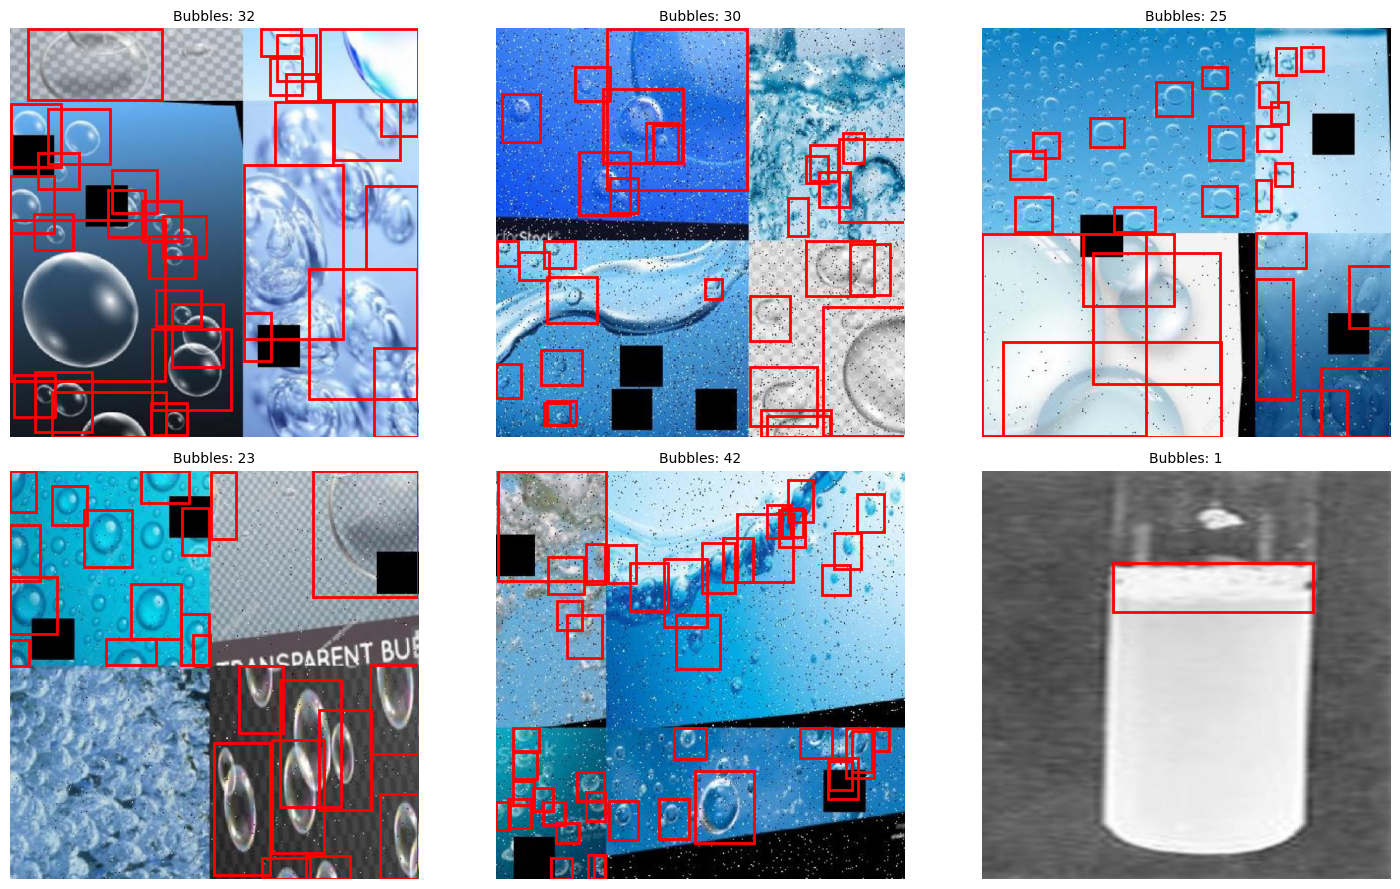

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample = images[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, img_path in enumerate(sample):
    pred = best_model.predict(img_path, conf=0.25, imgsz=640, verbose=False)[0]
    img  = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].axis('off')

    count = 0
    if pred.boxes is not None:
        for box in pred.boxes.xyxy.cpu().numpy():
            x1, y1, x2, y2 = box
            axes[i].add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            ))
            count += 1
    axes[i].set_title(f'Bubbles: {count}', fontsize=10)

plt.tight_layout()
plt.show()

## Evaluating on Validation Set


In [ ]:
import os

# Load the best checkpoint
best_model_path = str(results.save_dir) + "/weights/best.pt"
best_model = YOLO(best_model_path)

# Validate
metrics = best_model.val(data=DATA_YAML, imgsz=IMG_SIZE)

print("\n=== Validation Metrics ===")
print(f"mAP@0.5       : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {metrics.box.map:.4f}")
print(f"Precision     : {metrics.box.mp:.4f}")
print(f"Recall        : {metrics.box.mr:.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1923.4±586.5 MB/s, size: 53.8 KB)
val: Scanning /content/Trial2-3/valid/labels.cache... 56 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 23.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 79, len(boxes) = 1925. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.5s/it 9.9s
                   all         56       1925      0.748      0.723      0.757      0.419
                Bubble          5         77      0.795      0.805      0.831      0.595
                  Foam         15         15

## Plotting Training Curves


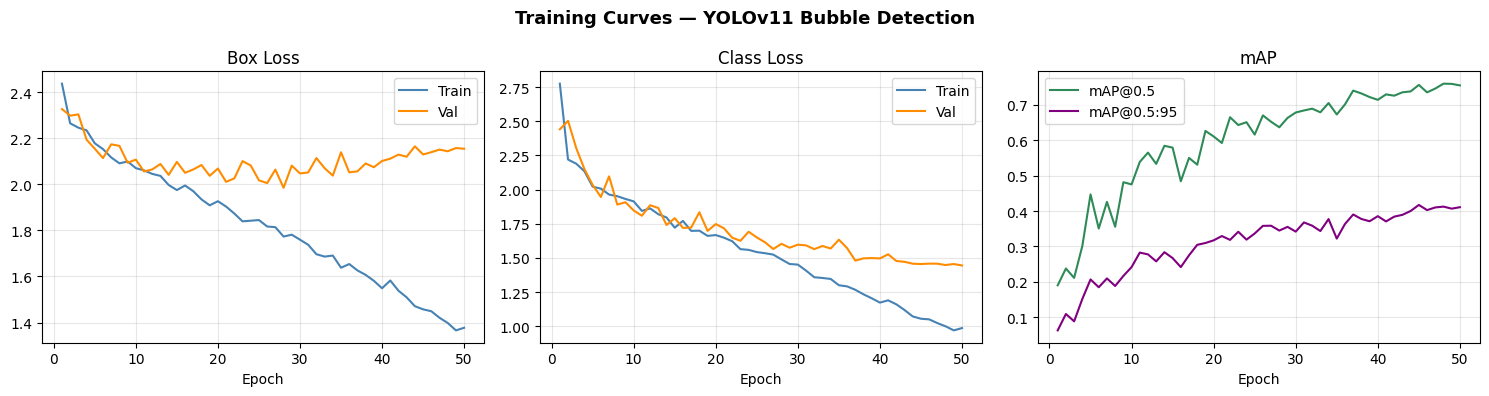

Saved: training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = str(results.save_dir) + '/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()   # remove whitespace from column names

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training Curves — YOLOv11 Bubble Detection', fontsize=13, fontweight='bold')

# Box loss
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train', color='steelblue')
axes[0].plot(df['epoch'], df['val/box_loss'],   label='Val',   color='darkorange')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Class loss
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train', color='steelblue')
axes[1].plot(df['epoch'], df['val/cls_loss'],   label='Val',   color='darkorange')
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# mAP
axes[2].plot(df['epoch'], df['metrics/mAP50(B)'],    label='mAP@0.5',    color='seagreen')
axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:95', color='purple')
axes[2].set_title('mAP')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")